# Same approval, months or days: rebuilding the evidence chart

Three panels, three official sources. Two are downloaded and checked automatically; one (a paywalled journal article) has a clearly marked manual step.

## Step 0. Set up

You need Python 3 with `requests`, `pypdf`, `pandas` and `matplotlib`
(`pip install requests pypdf pandas matplotlib`). Run the cells from top to bottom.
Downloaded documents go in `sources/`; the finished chart goes in `output/`.

In [1]:
# Chart style used on every chart: Google Sans if installed, white background, quiet grid,
# vertical columns, both axes drawn, sources printed with links in [brackets].
import logging
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib import font_manager

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
for font_file in Path.home().glob("Library/Fonts/GoogleSans-*.ttf"):
    font_manager.fontManager.addfont(str(font_file))
plt.rcParams.update({
    "font.family": ["Google Sans", "Arial", "DejaVu Sans"],
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#14213D",
    "axes.linewidth": 1.2,
    "axes.labelcolor": "#4F5B6E",
    "xtick.color": "#14213D",
    "ytick.color": "#4F5B6E",
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.color": "#E3E6EB",
    "figure.facecolor": "white",
})
BLUE, GREY, INK, MUTED = "#1F56A8", "#8A94A6", "#14213D", "#4F5B6E"

OUTPUT = Path("output")
OUTPUT.mkdir(exist_ok=True)


def frame_chart(fig, title, subtitle, sources, credit="Chart: Amy Chen"):
    """Title = the one takeaway; subtitle = what is plotted; footer = every source with its link."""
    fig.text(0.06, 0.94, title, fontsize=21, fontweight="bold", color=INK, va="top", wrap=True)
    fig.text(0.06, 0.865, subtitle, fontsize=13, color=MUTED, va="top")
    y = 0.075 + 0.032 * (len(sources) - 1)
    for label, url in sources:
        fig.text(0.06, y, f"Source: {label} [{url}]", fontsize=8.5, color=MUTED)
        y -= 0.032
    fig.text(0.94, 0.03, credit, fontsize=9, color=MUTED, ha="right")

In [2]:
# Download a file once and keep it in ./sources, so every later step reads the same copy.
import requests

SOURCES = Path("sources")
SOURCES.mkdir(exist_ok=True)
HEADERS = {"User-Agent": "Mozilla/5.0 (research notebook; reproducing a published chart)"}


def download(url, filename):
    path = SOURCES / filename
    if not path.exists():
        response = requests.get(url, headers=HEADERS, timeout=60)
        response.raise_for_status()
        path.write_bytes(response.content)
    print(f"{filename}: {path.stat().st_size:,} bytes")
    return path

In [3]:
# Read one page of a PDF as plain text, and print the sentence around a phrase.
import re

from pypdf import PdfReader


def page_text(pdf_path, page_number):
    """page_number is the PDF page (1 = first page of the file), not the number printed on the page."""
    text = PdfReader(pdf_path).pages[page_number - 1].extract_text()
    return " ".join(text.split())


def quote(text, phrase, before=220, after=200):
    at = text.find(phrase)
    assert at >= 0, f"'{phrase}' not found: the source may have changed"
    return "…" + text[max(0, at - before): at + len(phrase) + after] + "…"

## Step 1. Rooftop solar: SolarAPP+ vs traditional review

Source: National Laboratory of the Rockies (formerly NREL), *SolarAPP+ Performance Review*, Jan 2026.
The sentence is on PDF page 14 (printed page 8); Figure 8 on the next page charts it. Data year: 2024.

In [4]:
solar = download("https://docs.nlr.gov/docs/fy26osti/95050.pdf", "nlr-solarapp-2026.pdf")
p14 = page_text(solar, 14)
print(quote(p14, "were 7 days", before=150, after=200))

nlr-solarapp-2026.pdf: 1,736,278 bytes
… equal to median review times for traditional permits (Figure 8). The median permit review times for traditional PV-only and PV-plus-storage projects were 7 days.5 In contrast, SolarAPP+ facilitates instant permits for code-compliant applications, meaning that the median permit review duration for SolarAPP+ projects was zero days for both project types. Media…


In [5]:
solar_traditional_days, solar_app_days = 7, 0
assert "were 7 days" in p14 and "was zero days" in p14
print("SolarAPP+ numbers match page 14.")

SolarAPP+ numbers match page 14.


## Step 2. Los Angeles by-right vs discretionary housing (manual check)

Source: Manville, Monkkonen, Gray & Phillips, *JAPA* 2023, doi:10.1080/01944363.2022.2106291.
The journal blocks scripted downloads, so **this step is done by hand**:

1. Open https://doi.org/10.1080/01944363.2022.2106291 (or the APA summary: https://www.planning.org/blog/9272821/discretionary-vs-by-right-approval-which-is-faster/).
2. Find the result that by-right projects were permitted **60 days faster** inside the Transit Oriented Communities program and **248 days faster** outside it (n = 352, Jan 2018–Mar 2020).
3. Type the two numbers below. The cell records that they were entered by hand.

In [6]:
la_by_right_faster_days = {"Transit program (TOC)": 60, "Other projects": 248}
CHECKED_BY_HAND = True   # set after confirming in the paper; the chart refuses to draw otherwise
assert CHECKED_BY_HAND

## Step 3. Large renewables in New York: the deadline vs the whole process

Source: NY State Comptroller audit 2023-S-52, PDF page 11 (see notebook 01 for every step).

In [7]:
audit = download("https://www.osc.ny.gov/files/state-agencies/audits/pdf/sga-2024-23s52.pdf", "ny-comptroller-audit-2023-S-52.pdf")
p11 = page_text(audit, 11)
print(quote(p11, "within 1 year (365 days)", before=120, after=60))
ny_clock_days, ny_full_process_days = 365, 1333
assert "1 year (365 days)" in p11 and "1,333 days" in p11

ny-comptroller-audit-2023-S-52.pdf: 1,199,661 bytes
… website. Final Siting Permit ORES must make a final decision on a siting permit for any major renewable energy project within 1 year (365 days) from the date the application was deemed complete. Average …


## Step 4. Draw the three panels

Each panel compares two paths for the same kind of approval. Note the panels measure different things
(days saved, median review time, deadline vs total), so each has its own y-axis.

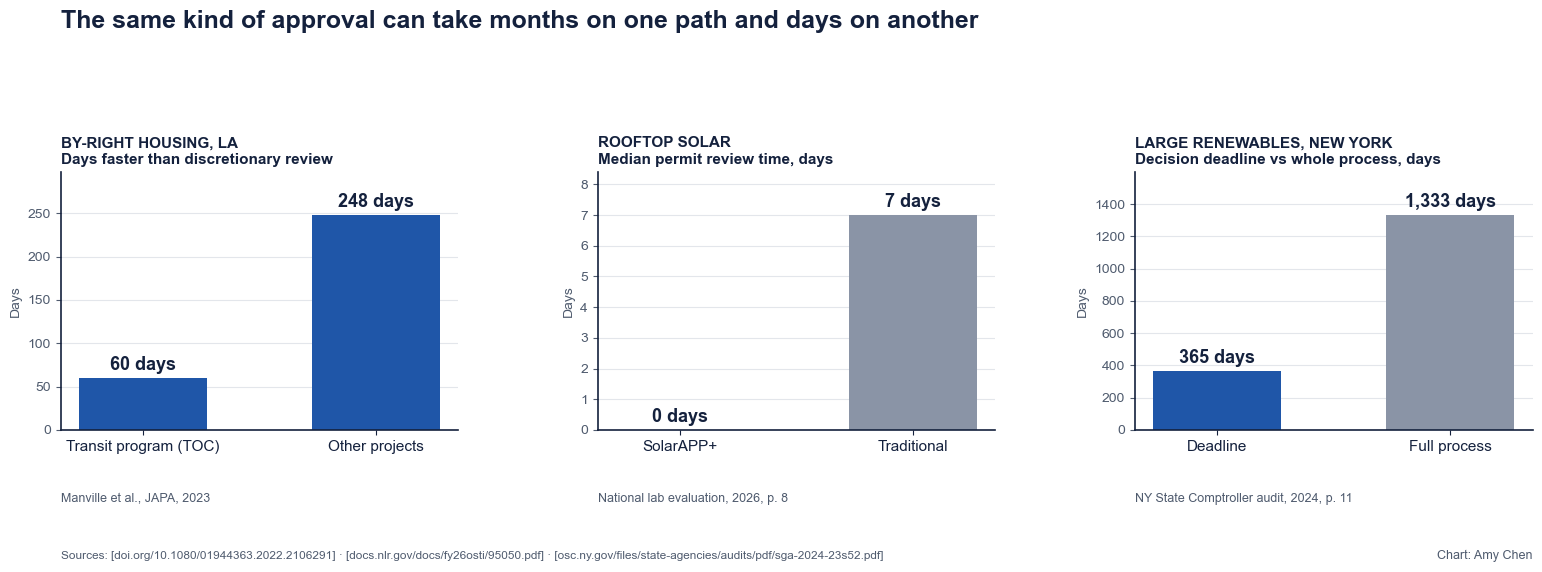

In [8]:
panels = [
    ("BY-RIGHT HOUSING, LA", "Days faster than discretionary review", list(la_by_right_faster_days), list(la_by_right_faster_days.values()), [BLUE, BLUE], "Manville et al., JAPA, 2023"),
    ("ROOFTOP SOLAR", "Median permit review time, days", ["SolarAPP+", "Traditional"], [solar_app_days, solar_traditional_days], [BLUE, GREY], "National lab evaluation, 2026, p. 8"),
    ("LARGE RENEWABLES, NEW YORK", "Decision deadline vs whole process, days", ["Deadline", "Full process"], [ny_clock_days, ny_full_process_days], [BLUE, GREY], "NY State Comptroller audit, 2024, p. 11"),
]
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.subplots_adjust(left=0.06, right=0.98, top=0.68, bottom=0.25, wspace=0.35)
for ax, (title, sub, labels, values, colors, src) in zip(axes, panels):
    ax.bar([0, 1], values, width=0.55, color=colors)
    for i, v in enumerate(values):
        ax.text(i, v + max(values) * 0.02, f"{v:,} days", ha="center", va="bottom", fontsize=13, fontweight="bold", color=INK)
    ax.set_xticks([0, 1], labels, fontsize=11)
    ax.set_ylabel("Days", fontsize=10)
    ax.set_ylim(0, max(values) * 1.2)
    ax.set_title(f"{title}\n{sub}", loc="left", fontsize=11, color=INK, fontweight="bold")
    ax.text(0, -0.28, src, transform=ax.transAxes, fontsize=9, color=MUTED)
    ax.set_axisbelow(True)
fig.text(0.06, 0.95, "The same kind of approval can take months on one path and days on another", fontsize=18, fontweight="bold", color=INK, va="top")
fig.text(0.06, 0.035, "Sources: [doi.org/10.1080/01944363.2022.2106291] · [docs.nlr.gov/docs/fy26osti/95050.pdf] · [osc.ny.gov/files/state-agencies/audits/pdf/sga-2024-23s52.pdf]", fontsize=8.5, color=MUTED)
fig.text(0.98, 0.035, "Chart: Amy Chen", fontsize=9, color=MUTED, ha="right")
fig.savefig(OUTPUT / "slow_vs_fast_approvals.png", dpi=200)
plt.show()

## Appendix A. Honolulu's AI pre-check (used in the post's text, not the chart)

Source: GovTech, July 2026, quoting Honolulu's Department of Planning and Permitting.

In [9]:
import html as _html
gov = download("https://www.govtech.com/artificial-intelligence/honolulu-launches-ai-assisted-fast-track-permit-review", "govtech-honolulu-2026.html")
gt = " ".join(_html.unescape(re.sub(r"<[^>]+>", " ", gov.read_text(encoding="utf-8"))).split())
print(quote(gt, "fell from 73 days to 32.5 days", before=80, after=140))
print()
print(quote(gt, "based on 19 CivCheck-processed", before=20, after=160))

govtech-honolulu-2026.html: 137,075 bytes
…at did not use the platform, the department said. DPP said average review times fell from 73 days to 32.5 days, reducing processing time by about 40.5 days per permit. Average plan review cycles also declined from 3.4 to 1.4 cycles. “These are the mo…

…hat the figures are based on 19 CivCheck-processed residential permits involving new construction, additions and alterations with comparable plan review data. The comparison group consisted of 17 similar non-Ci…


## Appendix B. LA's ED1 fast lane: a comparison to avoid

The LA City Planning report to Council (Dec 2023) gives **43 days** (page 3) for City Planning approval of ED1
projects, and **20–28 weeks** (page 7) for the *Housing Department's* covenant processing of *non-ED1* projects.
These are different stages handled by different departments, so "20–28 weeks → 43 days" is **not** a before/after of the
same approval. What page 7 does support: prioritizing ED1 lengthened processing for other projects.

In [10]:
ed1 = download("https://cityclerk.lacity.org/onlinedocs/2023/23-0623_rpt_plan_12-05-23.pdf", "la-ed1-report-2023.pdf")
print("p.3:", quote(page_text(ed1, 3), "within 43 days", before=120, after=60))
print()
print("p.7:", quote(page_text(ed1, 7), "concurrently been extended", before=80, after=260))

la-ed1-report-2023.pdf: 273,150 bytes
p.3: …llowing the submission of a completed application. Today, the average ED 1 project receives approval from City Planning within 43 days of a submitted complete application. Specific directive and…

p.7: …proved with these new staff. However, processing time for non -ED1 projects has concurrently been extended as ED1 projects are prioritized. Non-ED1 projects are currently processed in 8-12 calendar weeks for Replacement Unit Determinations, and in 12- 16 weeks for affordability covenants, f or a total of 20 -28 weeks. As such, LAHD would request two (2) additional…
